In [1]:
start_year = "2020"
holding_days = "7"
momentum_days = "30"
min_mcap = "1_000_000"
long_decile = "9"
short_decile = "-1"
max_longs = "20"
max_shorts = "1"

In [2]:
start_year_P = int(start_year)
holding_days_P = int(holding_days)
momentum_days_P = int(momentum_days)
min_mcap_P = float(min_mcap)
long_decile_P = int(long_decile)
short_decile_P = int(short_decile)
max_longs_P = int(max_longs)
max_shorts_P = int(max_shorts)

print(
    f"""
start_year: {start_year_P}
holding_days: {holding_days_P}
momentum_days: {momentum_days_P}
min_mcap: {min_mcap_P}
long_decile: {long_decile_P}
short_decile: {short_decile_P}
max_longs: {max_longs_P}
max_shorts: {max_shorts_P}
"""
)


start_year: 2020
holding_days: 7
momentum_days: 30
min_mcap: 1000000.0
long_decile: 9
short_decile: -1
max_longs: 20
max_shorts: 1



In [3]:
import datetime as dt
import polars as pl
import scrapbook as sb
import backtest as bt

# Load the daily OHLCV klines for USDT-quoted coins.
# We alias 'quote_volume' to 'mcap' to serve as our liquidity/market cap filter.
df = (
    pl.read_parquet("polarity/data/*.parquet")
    .sort(["asset", "ts"])
    .filter(
        ~pl.col("asset").is_in(
            ["bfusd", "busd", "dai", "fdusd", "rlusd", "susd", "tusd",
             "usd1", "usdc", "usde", "usdp", "usds", "usdsb", "xusd"]
        )
    )
    .with_columns(mom=pl.col("price").pct_change(momentum_days_P).over("asset"))
    .filter(pl.col("ts").dt.year() >= start_year_P)
    .drop_nulls(["mom",'price','total_volume'])
    .with_columns(
        decile=pl.col("mom")
        .qcut(10, labels=[str(i) for i in range(10)], allow_duplicates=True)
        .over("ts")
        .cast(pl.Utf8).cast(pl.Int8)
    )
    .sort("ts")
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2317/2317 [00:08<00:00, 270.21it/s]


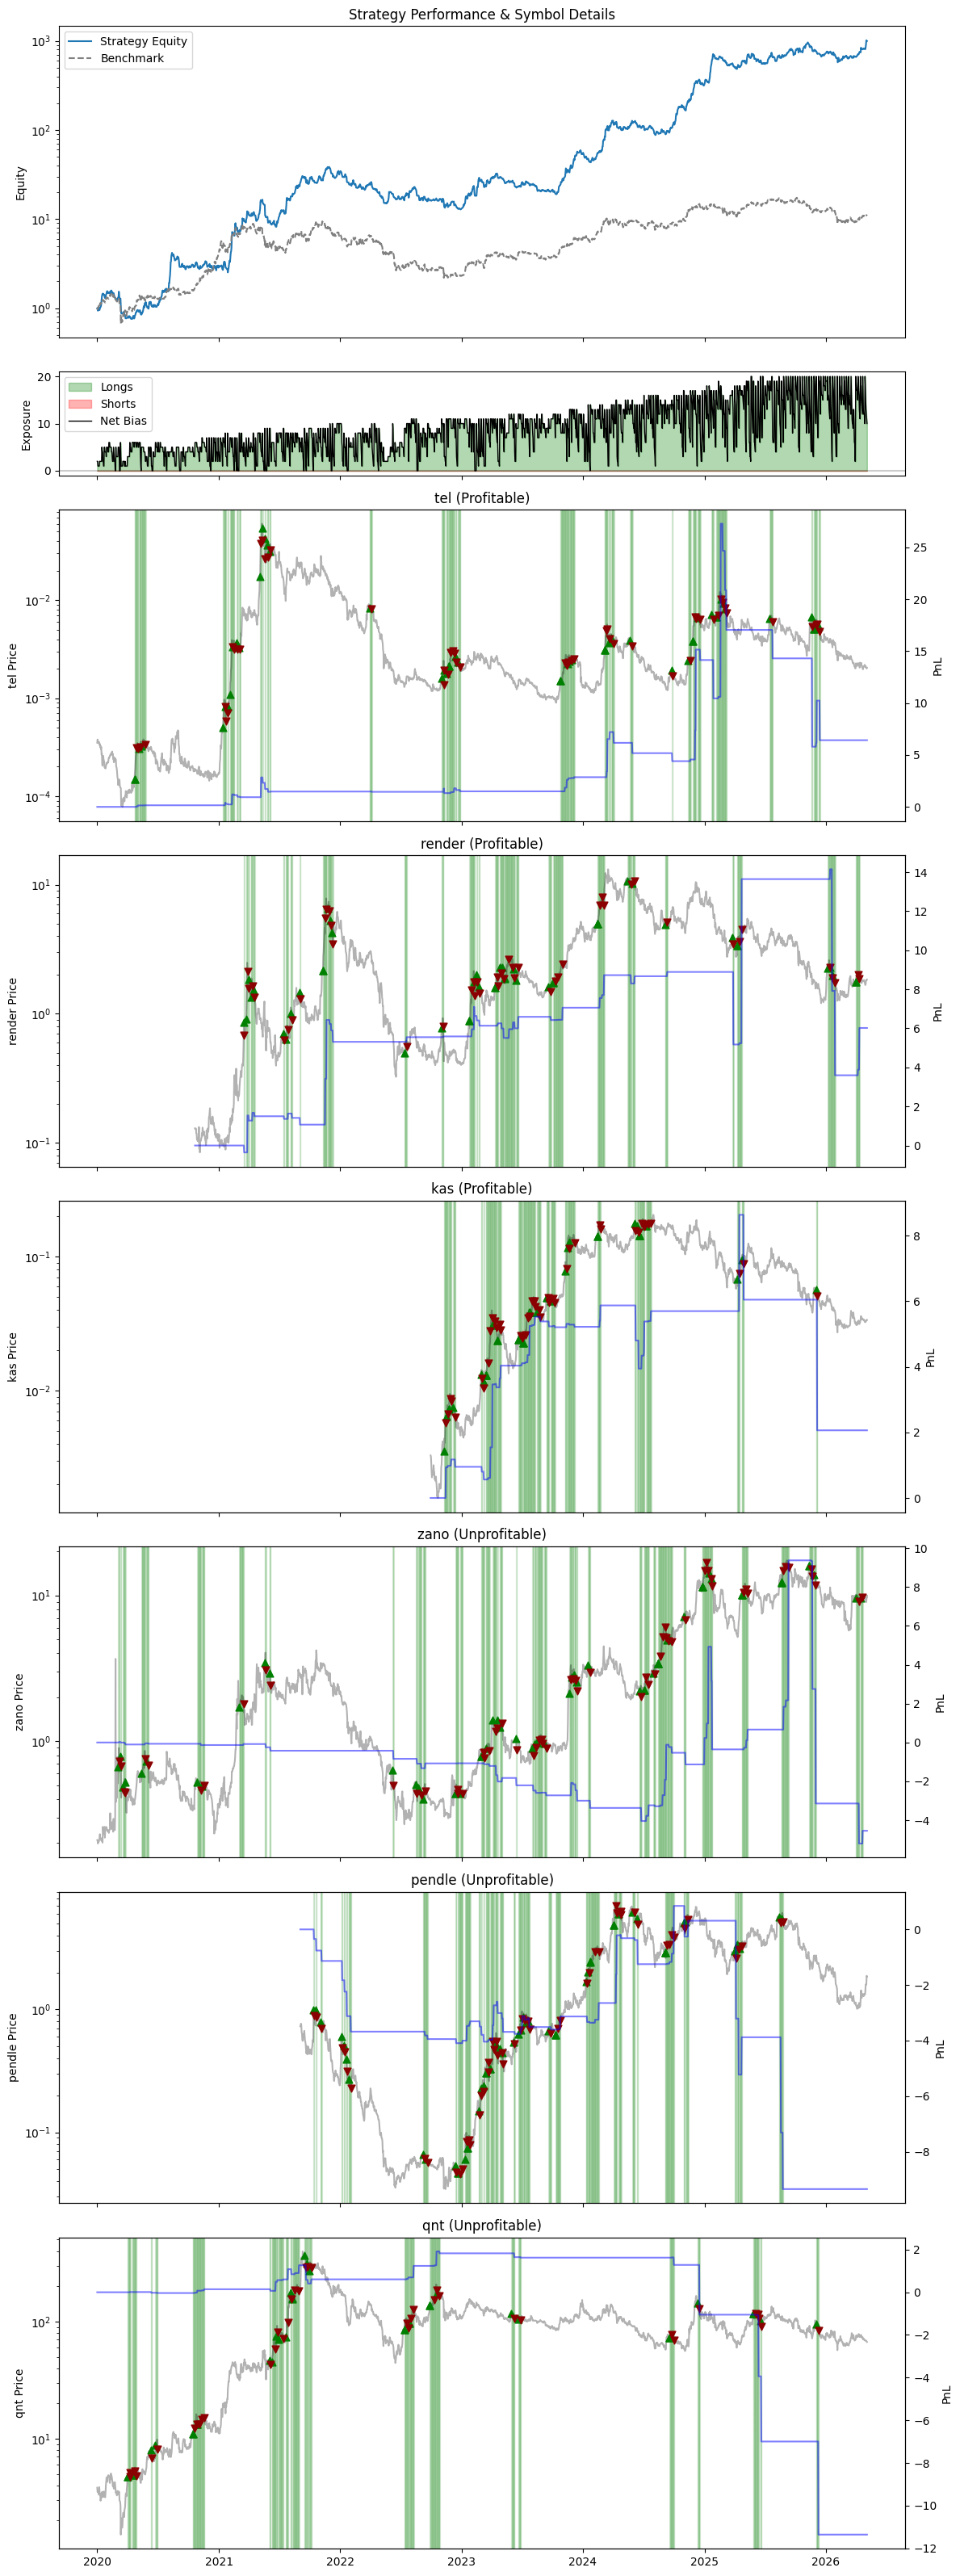

cagr: 3.2098 (0.7604)


sharpe: 1.5614 (0.7012)


mfe_std: 0.6009


ann_return: 0.8866 (0.3484)


mae_std: 0.0685


...

sortino: 3.2562 (1.2992)


ann_std: 0.5312 (0.4881)


win_rate: 0.4938


mae: -0.0644


mfe: 0.2358


In [4]:
class Alpha(bt.AlphaModel):
    def __init__(self, long_expr: pl.Expr, short_expr: pl.Expr):
        self.long_expr = long_expr
        self.short_expr = short_expr

    def __call__(self, df: pl.DataFrame) -> list[bt.Signal]:
        today = df["ts"].max()
        dfnow = df.filter(pl.col("ts") == today)

        l = dfnow.filter(self.long_expr).sort('mom', descending=True)
        s = dfnow.filter(self.short_expr).sort('mom', descending=False)

        return [
            bt.Signal(r["asset"], True, 1.0)
            for r in l.iter_rows(named=True)
        ][:max_longs_P] + [
            bt.Signal(r["asset"], False, 1.0)
            for r in s.iter_rows(named=True)
        ][:max_shorts_P]


# Setup conditional gating for optional long/short logic
if long_decile_P == -1:
    long_expr = pl.lit(False)
else:
    long_expr = (pl.col("decile") >= long_decile_P) & (pl.col("mom") > 0) & (pl.col("market_cap") >= min_mcap_P)


if short_decile_P == -1:
    short_expr = pl.lit(False)
else:
    short_expr = (pl.col("decile") <= short_decile_P) & (pl.col("mom") < 0) & (pl.col("market_cap") >= min_mcap_P)

test = bt.Backtest(
    df,
    alpha=Alpha(long_expr=long_expr, short_expr=short_expr),
    portfolio=bt.EqualWeight(price_col="price", symbol_col="asset"),
    #portfolio=bt.VolumeWeighted(price_col="price", symbol_col="asset", volume_col='total_volume'),
    risk=bt.MaxDrawdown(absolute=0.2,trailing=0.1,symbol_col='asset',price_col='price'),
    period=holding_days_P,
    eager_rebalance=False,
    initial_equity=1.0,
    symbol_col='asset',
    price_col='price',
    benchmark='btc',
)

test.run()

res = test.report(plot='brief')

def _fmt(v):
    return f"{v:.4f}" if v is not None else "N/A"

if not res.is_empty():
    for col in set(res.columns) - {"year", "src"}:
        s_df = res.filter(pl.col("src") == "Strategy")
        b_df = res.filter(pl.col("src") == "Benchmark")

        s_val = s_df[col].mean()
        b_val = b_df[col].mean() if not b_df.is_empty() else None

        if b_val is not None:
            print(f"{col}: {_fmt(s_val)} ({_fmt(b_val)})")
        else:
            print(f"{col}: {_fmt(s_val)}")

        if s_val is not None:
            sb.glue(col, float(s_val))
else:
    print("No trades executed.")